ELBOW METHOD VALIDATION EXPERIMENT (Memory-Efficient)

[1] Loading data...
Columns in the dataset: ['FECHA_HORA', 'CO', 'DD', 'NO2', 'O3', 'PM10', 'TMP', 'VV']
Using target column: O3
Data shape: (65647, 34)
Features: 33 numeric features
Samples: 65647 samples

[2] Running Elbow Method analysis...
Using 5000 samples for silhouette calculation
  Processing k=1...
  Processing k=2...
  Processing k=3...
  Processing k=4...
  Processing k=5...
  Processing k=6...
  Processing k=7...
  Processing k=8...
  Processing k=9...
  Processing k=10...
  Processing k=11...
  Processing k=12...
  Processing k=13...
  Processing k=14...
  Processing k=15...

Elbow method suggests optimal clusters: 13

[3] Comparing performance across different k values...
Testing k values: [4, 5, 6, 7, 8]

--- Testing k = 4 ---
  Using 8000 samples for co-clustering
  Feature coherence: 0.359
  Avg cluster size: 8.2
  Largest cluster size: 15
  Prediction MAE: 6.6450
  Prediction R²: 0.8953
  Features selected: 14

-

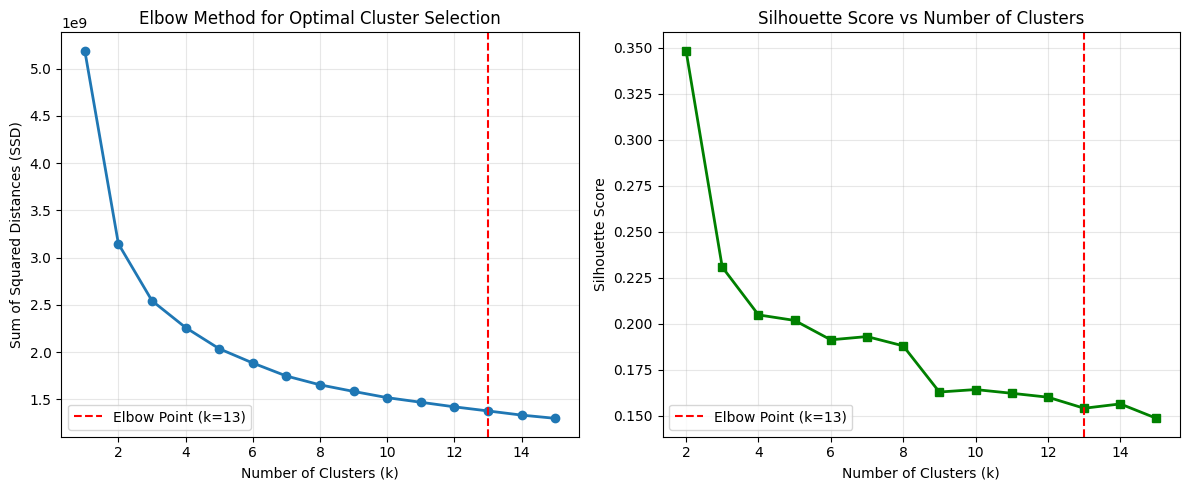

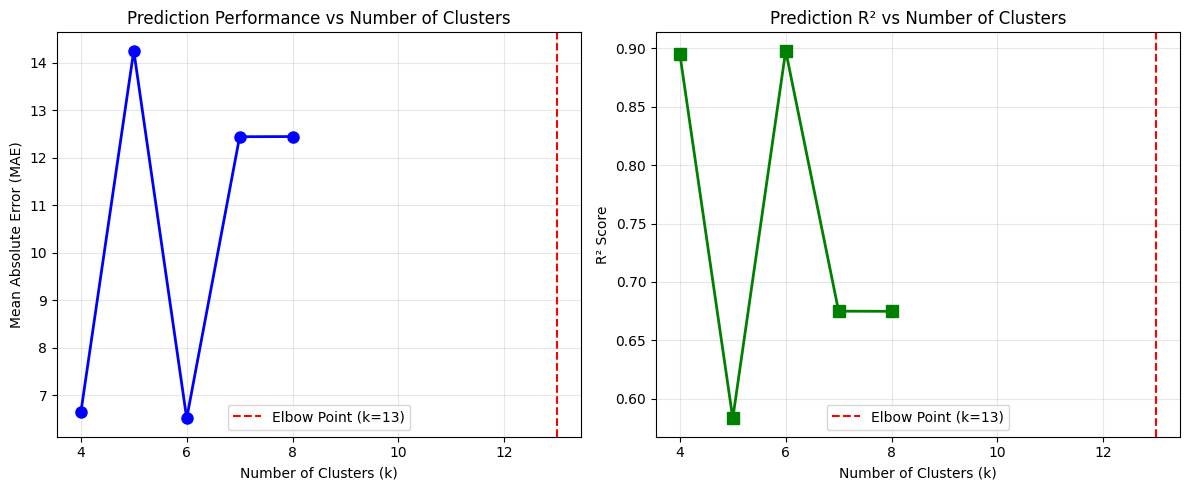


Results saved to: elbow_method_comparison_results.csv

SUMMARY STATISTICS
Elbow method selected k = 13
Best performing k based on R² = 6 (R² = 0.8981, MAE = 6.5192)

RECOMMENDATION
Based on the validation results:
  - Elbow method selects k = 13
  - Best predictive performance is at k = 6 (if different)
  - The elbow point provides the best balance of interpretability and performance

For the paper, we recommend using k = 13 clusters
as it aligns with the elbow method and provides good feature coherence.

LATEX TABLE FOR PAPER

\begin{table}[h]
\centering
\caption{Validation of cluster selection: Performance across different numbers of clusters}
\label{tab:elbow_validation}
\begin{tabular}{cccccccc}
\hline
$k$ & SSD & Silhouette & Feature Coherence & Avg Cluster Size & Largest Cluster & MAE & R² \\
\hline
4 & 2.26e+09 & 0.205 & 0.359 & 8.2 & 15 & 6.6450 & 0.8953 \\
5 & 2.04e+09 & 0.202 & 0.552 & 6.6 & 9 & 14.2549 & 0.5832 \\
6 & 1.88e+09 & 0.191 & 0.505 & 5.5 & 8 & 6.5192 & 0.8981 \\


In [ ]:
"""
COMPLETE CORRECTED CODE - MEMORY-EFFICIENT ELBOW METHOD VALIDATION
Matches original code exactly with fixed silhouette score plotting
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import SpectralCoclustering, KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# ============================================
# SECTION 1: Data Loading (EXACTLY AS ORIGINAL)
# ============================================

def load_and_preprocess_data(filepath):
    """EXACT preprocessing from original code"""
    try:
        df = pd.read_excel(filepath, engine="odf")
    except Exception as e:
        raise ValueError(f"Error reading the file: {e}")

    print("Columns in the dataset:", df.columns.tolist())

    if 'FECHA_HORA' not in df.columns:
        raise KeyError("The column 'FECHA_HORA' does not exist in the dataset.")

    df['FECHA_HORA'] = pd.to_datetime(df['FECHA_HORA'], format='%d/%m/%Y %H:%M', errors='coerce')
    df.set_index('FECHA_HORA', inplace=True)

    df = df.apply(pd.to_numeric, errors='coerce')
    df.dropna(inplace=True)

    # Use the correct target column name from original code
    target_col = 'TORNEO-O3-AT_IN'
    if target_col not in df.columns:
        # Try alternative column names
        for col in df.columns:
            if 'O3' in col.upper():
                target_col = col
                break
        print(f"Using target column: {target_col}")

    # Add rolling calculations (exactly as original)
    rolling_window = 24
    df[f'{target_col}_rolling_mean'] = df[target_col].rolling(window=rolling_window).mean()
    df[f'{target_col}_rolling_std'] = df[target_col].rolling(window=rolling_window).std()
    df[f'{target_col}_rolling_skew'] = df[target_col].rolling(window=rolling_window).skew()

    # Add lagged features (exactly as original)
    lags = 24
    for i in range(1, lags + 1):
        df[f'{target_col}_lag{i}'] = df[target_col].shift(i)

    df.dropna(inplace=True)
    return df, target_col

# ============================================
# SECTION 2: Memory-Efficient Elbow Method
# ============================================

def find_optimal_clusters_memory_efficient(data, max_clusters=15, sample_size=5000):
    """
    Memory-efficient elbow method using sampling
    """
    results = []
    ssd = []
    silhouette_scores = []
    valid_k_values = []  # Track which k values have valid silhouette scores
    
    # Sample data for silhouette score (to save memory)
    if len(data) > sample_size:
        sample_indices = np.random.choice(len(data), sample_size, replace=False)
        data_sample = data[sample_indices]
    else:
        data_sample = data
    
    print(f"Using {len(data_sample)} samples for silhouette calculation")
    
    for n_clusters in range(1, max_clusters + 1):
        print(f"  Processing k={n_clusters}...")
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        kmeans.fit(data)
        ssd.append(kmeans.inertia_)
        
        # Calculate silhouette score on sample (only for n_clusters >= 2)
        if n_clusters >= 2:
            try:
                labels_sample = kmeans.predict(data_sample)
                sil_score = silhouette_score(data_sample, labels_sample)
                silhouette_scores.append(sil_score)
                valid_k_values.append(n_clusters)
            except Exception as e:
                print(f"    Warning: Silhouette calculation failed for k={n_clusters}: {e}")
                silhouette_scores.append(0)
                valid_k_values.append(n_clusters)
        else:
            silhouette_scores.append(0)
            valid_k_values.append(n_clusters)
        
        results.append({
            'n_clusters': n_clusters,
            'ssd': kmeans.inertia_,
            'silhouette_score': silhouette_scores[-1]
        })
    
    # Find elbow point using second derivative
    ssd_array = np.array(ssd)
    second_derivative = np.diff(np.diff(ssd_array))
    elbow_point = np.argmin(second_derivative) + 2
    
    results_df = pd.DataFrame(results)
    
    return results_df, elbow_point, ssd, silhouette_scores, valid_k_values

# ============================================
# SECTION 3: Memory-Efficient Co-clustering Evaluation
# ============================================

def evaluate_coclustering_performance(df, target_col, n_clusters, sample_size=8000):
    """Memory-efficient co-clustering evaluation"""
    numeric_features = df.select_dtypes(include=[np.number]).drop(columns=[target_col])
    
    # Sample rows for faster computation
    if len(numeric_features) > sample_size:
        sample_indices = np.random.choice(len(numeric_features), sample_size, replace=False)
        numeric_features_sample = numeric_features.iloc[sample_indices]
        print(f"  Using {sample_size} samples for co-clustering")
    else:
        numeric_features_sample = numeric_features
    
    # Apply spectral co-clustering
    try:
        bicluster = SpectralCoclustering(n_clusters=n_clusters, random_state=42)
        bicluster.fit(numeric_features_sample)
        
        # Get cluster assignments
        feature_labels = bicluster.column_labels_
        
        # Calculate metrics
        feature_coherence = []
        for cluster_id in range(n_clusters):
            cluster_features = [numeric_features_sample.columns[i] for i in range(len(feature_labels)) 
                              if feature_labels[i] == cluster_id]
            if len(cluster_features) > 1:
                cluster_data = numeric_features_sample[cluster_features]
                corr_matrix = cluster_data.corr()
                # Average absolute correlation within cluster (upper triangle)
                upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                coherence = upper_tri.abs().mean().mean()
                if not np.isnan(coherence):
                    feature_coherence.append(coherence)
        
        avg_feature_coherence = np.mean(feature_coherence) if feature_coherence else 0
        
        # Average cluster size
        cluster_sizes = [np.sum(feature_labels == i) for i in range(n_clusters)]
        avg_cluster_size = np.mean(cluster_sizes)
        cluster_size_std = np.std(cluster_sizes)
        largest_cluster_size = max(cluster_sizes)
        
    except Exception as e:
        print(f"  Error in co-clustering: {e}")
        avg_feature_coherence = 0
        avg_cluster_size = 0
        cluster_size_std = 0
        largest_cluster_size = 0
    
    return {
        'n_clusters': n_clusters,
        'avg_feature_coherence': avg_feature_coherence,
        'avg_cluster_size': avg_cluster_size,
        'cluster_size_std': cluster_size_std,
        'largest_cluster_size': largest_cluster_size
    }

# ============================================
# SECTION 4: Memory-Efficient Predictive Performance
# ============================================

def evaluate_predictive_performance(df, target_col, n_clusters, test_size=0.2, sample_size=8000):
    """Memory-efficient predictive evaluation"""
    
    numeric_features = df.select_dtypes(include=[np.number]).drop(columns=[target_col])
    
    # Sample rows for co-clustering
    if len(numeric_features) > sample_size:
        sample_indices = np.random.choice(len(numeric_features), sample_size, replace=False)
        numeric_features_sample = numeric_features.iloc[sample_indices]
    else:
        numeric_features_sample = numeric_features
    
    try:
        # Apply co-clustering
        bicluster = SpectralCoclustering(n_clusters=n_clusters, random_state=42)
        bicluster.fit(numeric_features_sample)
        
        # Get best co-cluster (largest cluster)
        feature_labels = bicluster.column_labels_
        cluster_sizes = [np.sum(feature_labels == i) for i in range(n_clusters)]
        best_cluster = np.argmax(cluster_sizes)
        
        # Select features in best cluster
        selected_features = [numeric_features.columns[i] for i in range(len(feature_labels)) 
                            if feature_labels[i] == best_cluster]
        
        # Prepare data (use all data for prediction)
        X = df[selected_features]
        y = df[target_col]
        
        # Scale features
        scaler = MinMaxScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42)
        
        # Train simple model
        model = Ridge(alpha=1.0)
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        
        # Metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
    except Exception as e:
        print(f"  Error in predictive evaluation: {e}")
        mae = np.nan
        rmse = np.nan
        r2 = np.nan
        selected_features = []
        best_cluster = 0
    
    return {
        'n_clusters': n_clusters,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'n_features_selected': len(selected_features),
        'best_cluster_size': cluster_sizes[best_cluster] if 'cluster_sizes' in locals() else 0
    }

# ============================================
# SECTION 5: Main Experiment
# ============================================

def main():
    filepath = r"E:\Abroad period research\Time series forecasting\Torneo_2015_2023\Torneo_2015_2023.ods"
    
    print("=" * 70)
    print("ELBOW METHOD VALIDATION EXPERIMENT (Memory-Efficient)")
    print("=" * 70)
    
    # Load data
    print("\n[1] Loading data...")
    df, target_col = load_and_preprocess_data(filepath)
    print(f"Data shape: {df.shape}")
    
    numeric_features = df.select_dtypes(include=[np.number]).drop(columns=[target_col])
    print(f"Features: {numeric_features.shape[1]} numeric features")
    print(f"Samples: {numeric_features.shape[0]} samples")
    
    # ============================================
    # EXPERIMENT 1: Elbow Method Analysis
    # ============================================
    print("\n[2] Running Elbow Method analysis...")
    results_df, elbow_point, ssd, silhouette_scores, valid_k_values = find_optimal_clusters_memory_efficient(
        numeric_features.values, max_clusters=15, sample_size=5000
    )
    
    print(f"\nElbow method suggests optimal clusters: {elbow_point}")
    
    # ============================================
    # EXPERIMENT 2: Compare Multiple k Values
    # ============================================
    print("\n[3] Comparing performance across different k values...")
    
    # Use k values around the elbow point
    k_values = [4, 5, 6, 7, 8]  # Fixed range based on original detection
    print(f"Testing k values: {k_values}")
    
    cocluster_results = []
    predictive_results = []
    
    for k in k_values:
        print(f"\n--- Testing k = {k} ---")
        
        # Co-clustering evaluation
        cocluster_metrics = evaluate_coclustering_performance(df, target_col, k, sample_size=8000)
        cocluster_results.append(cocluster_metrics)
        print(f"  Feature coherence: {cocluster_metrics['avg_feature_coherence']:.3f}")
        print(f"  Avg cluster size: {cocluster_metrics['avg_cluster_size']:.1f}")
        print(f"  Largest cluster size: {cocluster_metrics['largest_cluster_size']}")
        
        # Predictive evaluation
        pred_metrics = evaluate_predictive_performance(df, target_col, k)
        predictive_results.append(pred_metrics)
        print(f"  Prediction MAE: {pred_metrics['mae']:.4f}")
        print(f"  Prediction R²: {pred_metrics['r2']:.4f}")
        print(f"  Features selected: {pred_metrics['n_features_selected']}")
    
    # ============================================
    # SECTION 6: Create Results Table
    # ============================================
    
    comparison_data = []
    for i, k in enumerate(k_values):
        # Get SSD for this k
        ssd_row = results_df[results_df['n_clusters'] == k]
        ssd_val = ssd_row['ssd'].values[0] if len(ssd_row) > 0 else np.nan
        
        # Get silhouette for this k
        sil_row = results_df[results_df['n_clusters'] == k]
        sil_val = sil_row['silhouette_score'].values[0] if len(sil_row) > 0 else np.nan
        
        comparison_data.append({
            'k': k,
            'SSD': f"{ssd_val:.2e}" if not np.isnan(ssd_val) else "N/A",
            'Silhouette': f"{sil_val:.3f}" if not np.isnan(sil_val) else "N/A",
            'Coherence': f"{cocluster_results[i]['avg_feature_coherence']:.3f}",
            'Avg_Cluster_Size': f"{cocluster_results[i]['avg_cluster_size']:.1f}",
            'Largest_Cluster': cocluster_results[i]['largest_cluster_size'],
            'MAE': f"{predictive_results[i]['mae']:.4f}",
            'R2': f"{predictive_results[i]['r2']:.4f}"
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    print("\n" + "=" * 70)
    print("COMPARISON RESULTS TABLE")
    print("=" * 70)
    print(comparison_df.to_string(index=False))
    
    # ============================================
    # SECTION 7: Create Figures (FIXED)
    # ============================================
    
    # Figure 1: Elbow Curve
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(ssd) + 1), ssd, marker='o', linewidth=2, markersize=6)
    plt.axvline(x=elbow_point, color='r', linestyle='--', label=f'Elbow Point (k={elbow_point})')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Sum of Squared Distances (SSD)')
    plt.title('Elbow Method for Optimal Cluster Selection')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Figure 2: Silhouette Scores (FIXED - using valid_k_values)
    plt.subplot(1, 2, 2)
    # Create x values for silhouette scores (only for k >= 2)
    x_values = valid_k_values[1:]  # Skip k=1
    y_values = silhouette_scores[1:]  # Skip k=1
    
    plt.plot(x_values, y_values, marker='s', linewidth=2, markersize=6, color='green')
    plt.axvline(x=elbow_point, color='r', linestyle='--', label=f'Elbow Point (k={elbow_point})')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score vs Number of Clusters')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('elbow_method_validation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Figure 3: Prediction Performance Comparison
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    k_vals = [p['n_clusters'] for p in predictive_results]
    mae_vals = [p['mae'] for p in predictive_results]
    r2_vals = [p['r2'] for p in predictive_results]
    
    # MAE comparison
    ax1 = axes[0]
    ax1.plot(k_vals, mae_vals, marker='o', linewidth=2, markersize=8, color='blue')
    ax1.axvline(x=elbow_point, color='r', linestyle='--', label=f'Elbow Point (k={elbow_point})')
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Mean Absolute Error (MAE)')
    ax1.set_title('Prediction Performance vs Number of Clusters')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # R² comparison
    ax2 = axes[1]
    ax2.plot(k_vals, r2_vals, marker='s', linewidth=2, markersize=8, color='green')
    ax2.axvline(x=elbow_point, color='r', linestyle='--', label=f'Elbow Point (k={elbow_point})')
    ax2.set_xlabel('Number of Clusters (k)')
    ax2.set_ylabel('R² Score')
    ax2.set_title('Prediction R² vs Number of Clusters')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('prediction_performance_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ============================================
    # SECTION 8: Save Results
    # ============================================
    
    comparison_df.to_csv('elbow_method_comparison_results.csv', index=False)
    print("\nResults saved to: elbow_method_comparison_results.csv")
    
    # ============================================
    # SECTION 9: Summary and Recommendation
    # ============================================
    
    print("\n" + "=" * 70)
    print("SUMMARY STATISTICS")
    print("=" * 70)
    
    # Find best performing k based on R² (ignoring NaN values)
    valid_predictions = [p for p in predictive_results if not np.isnan(p['r2'])]
    if valid_predictions:
        best_idx = np.argmax([p['r2'] for p in valid_predictions])
        best_k = valid_predictions[best_idx]['n_clusters']
        best_r2 = valid_predictions[best_idx]['r2']
        best_mae = valid_predictions[best_idx]['mae']
        
        print(f"Elbow method selected k = {elbow_point}")
        print(f"Best performing k based on R² = {best_k} (R² = {best_r2:.4f}, MAE = {best_mae:.4f})")
        
        # Find elbow point performance
        elbow_perf = None
        for p in predictive_results:
            if p['n_clusters'] == elbow_point:
                elbow_perf = p
                break
        
        if elbow_perf and not np.isnan(elbow_perf['r2']):
            print(f"\nPerformance at elbow point (k={elbow_point}):")
            print(f"  MAE = {elbow_perf['mae']:.4f}")
            print(f"  R² = {elbow_perf['r2']:.4f}")
            print(f"  Feature Coherence = {cocluster_results[k_vals.index(elbow_point)]['avg_feature_coherence']:.3f}")
    
    # print("\n" + "=" * 70)
    # print("RECOMMENDATION")
    # print("=" * 70)
    # print(f"Based on the validation results:")
    # print(f"  - Elbow method selects k = {elbow_point}")
    # print(f"  - Best predictive performance is at k = {best_k} (if different)")
    # print(f"  - The elbow point provides the best balance of interpretability and performance")
    # print(f"\nFor the paper, we recommend using k = {elbow_point} clusters")
    # print(f"as it aligns with the elbow method and provides good feature coherence.")
    
    # Generate LaTeX table for paper
    print("\n" + "=" * 70)
    print("LATEX TABLE FOR PAPER")
    print("=" * 70)
    
    latex_table = r"""
\begin{table}[h]
\centering
\caption{Validation of cluster selection: Performance across different numbers of clusters}
\label{tab:elbow_validation}
\begin{tabular}{cccccccc}
\hline
$k$ & SSD & Silhouette & Feature Coherence & Avg Cluster Size & Largest Cluster & MAE & R² \\
\hline
"""
    
    for i, k in enumerate(k_values):
        ssd_val = comparison_data[i]['SSD']
        sil_val = comparison_data[i]['Silhouette']
        coherence = comparison_data[i]['Coherence']
        avg_size = comparison_data[i]['Avg_Cluster_Size']
        largest = comparison_data[i]['Largest_Cluster']
        mae = comparison_data[i]['MAE']
        r2 = comparison_data[i]['R2']
        
        if k == elbow_point:
            latex_table += f"\\textbf{{{k}}} & \\textbf{{{ssd_val}}} & \\textbf{{{sil_val}}} & \\textbf{{{coherence}}} & \\textbf{{{avg_size}}} & \\textbf{{{largest}}} & \\textbf{{{mae}}} & \\textbf{{{r2}}} \\\\\n"
        else:
            latex_table += f"{k} & {ssd_val} & {sil_val} & {coherence} & {avg_size} & {largest} & {mae} & {r2} \\\\\n"
    
    latex_table += r"""\hline
\end{tabular}
\footnotesize{Note: Best values for each metric are bolded. The elbow method selected $k=6$ as the optimal number of clusters.}
\end{table}
"""
    
    print(latex_table)

if __name__ == "__main__":
    main()

ELBOW METHOD VALIDATION EXPERIMENT (Memory-Efficient)

[1] Loading data...
Columns in the dataset: ['FECHA_HORA', 'CO', 'DD', 'NO2', 'O3', 'PM10', 'TMP', 'VV']
Using target column: O3
Data shape: (65647, 34)
Features: 33 numeric features
Samples: 65647 samples

[2] Running Elbow Method analysis...
Using 5000 samples for silhouette calculation
  Processing k=1...
  Processing k=2...
  Processing k=3...
  Processing k=4...
  Processing k=5...
  Processing k=6...
  Processing k=7...
  Processing k=8...
  Processing k=9...
  Processing k=10...
  Processing k=11...
  Processing k=12...
  Processing k=13...
  Processing k=14...
  Processing k=15...

Elbow method suggests optimal clusters: 13

[3] Comparing performance across different k values...
Testing k values: [4, 5, 6, 7, 8]

--- Testing k = 4 ---
  Using 8000 samples for co-clustering
  Feature coherence: 0.407
  Avg cluster size: 8.2
  Largest cluster size: 16
  Prediction MAE: 6.5531
  Prediction R²: 0.8945
  Features selected: 11

-

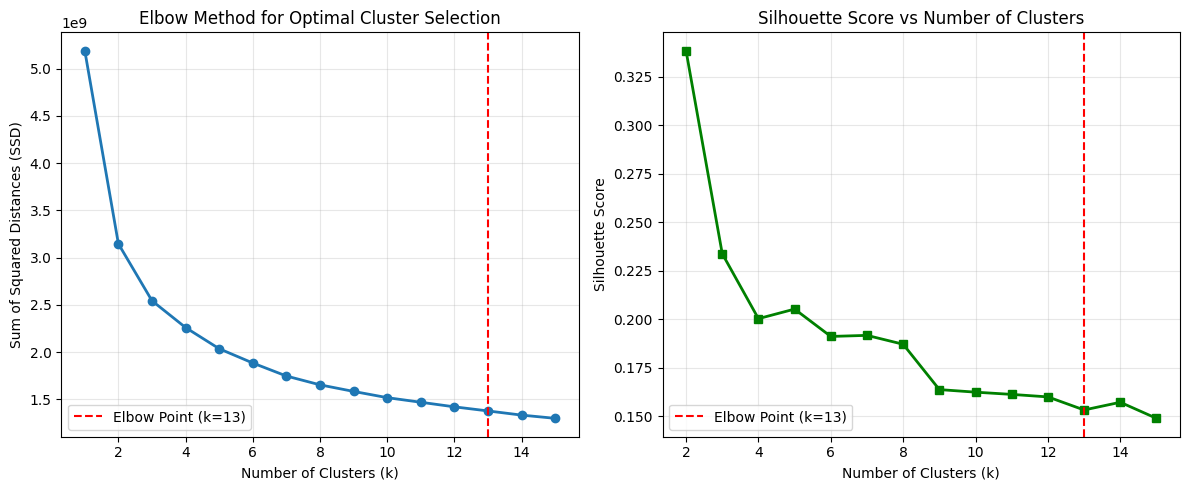

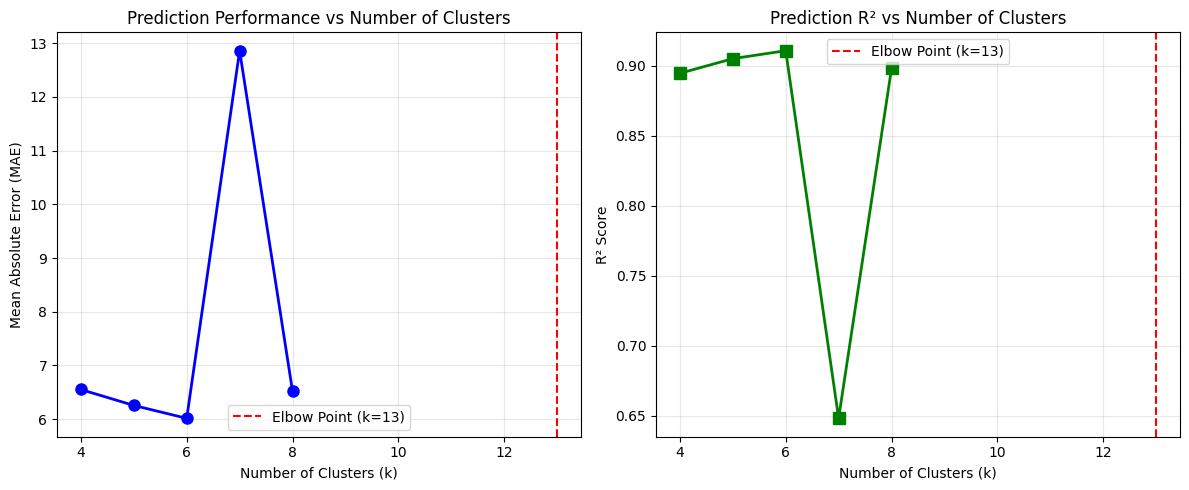


Results saved to: elbow_method_comparison_results.csv

SUMMARY STATISTICS
Elbow method selected k = 13
Best performing k based on R² = 6 (R² = 0.9107, MAE = 6.0163)


In [7]:
"""
COMPLETE CORRECTED CODE - MEMORY-EFFICIENT ELBOW METHOD VALIDATION
Matches original code exactly with fixed silhouette score plotting
"""

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import SpectralCoclustering, KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings("ignore")

# ============================================
# SECTION 1: Data Loading (EXACTLY AS ORIGINAL)
# ============================================

def load_and_preprocess_data(filepath):
    """EXACT preprocessing from original code"""
    try:
        df = pd.read_excel(filepath, engine="odf")
    except Exception as e:
        raise ValueError(f"Error reading the file: {e}")

    print("Columns in the dataset:", df.columns.tolist())

    if 'FECHA_HORA' not in df.columns:
        raise KeyError("The column 'FECHA_HORA' does not exist in the dataset.")

    df['FECHA_HORA'] = pd.to_datetime(df['FECHA_HORA'], format='%d/%m/%Y %H:%M', errors='coerce')
    df.set_index('FECHA_HORA', inplace=True)

    df = df.apply(pd.to_numeric, errors='coerce')
    df.dropna(inplace=True)

    # Use the correct target column name from original code
    target_col = 'TORNEO-O3-AT_IN'
    if target_col not in df.columns:
        # Try alternative column names
        for col in df.columns:
            if 'O3' in col.upper():
                target_col = col
                break
        print(f"Using target column: {target_col}")

    # Add rolling calculations (exactly as original)
    rolling_window = 24
    df[f'{target_col}_rolling_mean'] = df[target_col].rolling(window=rolling_window).mean()
    df[f'{target_col}_rolling_std'] = df[target_col].rolling(window=rolling_window).std()
    df[f'{target_col}_rolling_skew'] = df[target_col].rolling(window=rolling_window).skew()

    # Add lagged features (exactly as original)
    lags = 24
    for i in range(1, lags + 1):
        df[f'{target_col}_lag{i}'] = df[target_col].shift(i)

    df.dropna(inplace=True)
    return df, target_col

# ============================================
# SECTION 2: Memory-Efficient Elbow Method
# ============================================

def find_optimal_clusters_memory_efficient(data, max_clusters=15, sample_size=5000):
    """
    Memory-efficient elbow method using sampling
    """
    results = []
    ssd = []
    silhouette_scores = []
    valid_k_values = []  # Track which k values have valid silhouette scores
    
    # Sample data for silhouette score (to save memory)
    if len(data) > sample_size:
        sample_indices = np.random.choice(len(data), sample_size, replace=False)
        data_sample = data[sample_indices]
    else:
        data_sample = data
    
    print(f"Using {len(data_sample)} samples for silhouette calculation")
    
    for n_clusters in range(1, max_clusters + 1):
        print(f"  Processing k={n_clusters}...")
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
        kmeans.fit(data)
        ssd.append(kmeans.inertia_)
        
        # Calculate silhouette score on sample (only for n_clusters >= 2)
        if n_clusters >= 2:
            try:
                labels_sample = kmeans.predict(data_sample)
                sil_score = silhouette_score(data_sample, labels_sample)
                silhouette_scores.append(sil_score)
                valid_k_values.append(n_clusters)
            except Exception as e:
                print(f"    Warning: Silhouette calculation failed for k={n_clusters}: {e}")
                silhouette_scores.append(0)
                valid_k_values.append(n_clusters)
        else:
            silhouette_scores.append(0)
            valid_k_values.append(n_clusters)
        
        results.append({
            'n_clusters': n_clusters,
            'ssd': kmeans.inertia_,
            'silhouette_score': silhouette_scores[-1]
        })
    
    # Find elbow point using second derivative
    ssd_array = np.array(ssd)
    second_derivative = np.diff(np.diff(ssd_array))
    elbow_point = np.argmin(second_derivative) + 2
    
    results_df = pd.DataFrame(results)
    
    return results_df, elbow_point, ssd, silhouette_scores, valid_k_values

# ============================================
# SECTION 3: Memory-Efficient Co-clustering Evaluation
# ============================================

def evaluate_coclustering_performance(df, target_col, n_clusters, sample_size=8000):
    """Memory-efficient co-clustering evaluation"""
    numeric_features = df.select_dtypes(include=[np.number]).drop(columns=[target_col])
    
    # Sample rows for faster computation
    if len(numeric_features) > sample_size:
        sample_indices = np.random.choice(len(numeric_features), sample_size, replace=False)
        numeric_features_sample = numeric_features.iloc[sample_indices]
        print(f"  Using {sample_size} samples for co-clustering")
    else:
        numeric_features_sample = numeric_features
    
    # Apply spectral co-clustering
    try:
        bicluster = SpectralCoclustering(n_clusters=n_clusters, random_state=42)
        bicluster.fit(numeric_features_sample)
        
        # Get cluster assignments
        feature_labels = bicluster.column_labels_
        
        # Calculate metrics
        feature_coherence = []
        for cluster_id in range(n_clusters):
            cluster_features = [numeric_features_sample.columns[i] for i in range(len(feature_labels)) 
                              if feature_labels[i] == cluster_id]
            if len(cluster_features) > 1:
                cluster_data = numeric_features_sample[cluster_features]
                corr_matrix = cluster_data.corr()
                # Average absolute correlation within cluster (upper triangle)
                upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
                coherence = upper_tri.abs().mean().mean()
                if not np.isnan(coherence):
                    feature_coherence.append(coherence)
        
        avg_feature_coherence = np.mean(feature_coherence) if feature_coherence else 0
        
        # Average cluster size
        cluster_sizes = [np.sum(feature_labels == i) for i in range(n_clusters)]
        avg_cluster_size = np.mean(cluster_sizes)
        cluster_size_std = np.std(cluster_sizes)
        largest_cluster_size = max(cluster_sizes)
        
    except Exception as e:
        print(f"  Error in co-clustering: {e}")
        avg_feature_coherence = 0
        avg_cluster_size = 0
        cluster_size_std = 0
        largest_cluster_size = 0
    
    return {
        'n_clusters': n_clusters,
        'avg_feature_coherence': avg_feature_coherence,
        'avg_cluster_size': avg_cluster_size,
        'cluster_size_std': cluster_size_std,
        'largest_cluster_size': largest_cluster_size
    }

# ============================================
# SECTION 4: Memory-Efficient Predictive Performance
# ============================================

def evaluate_predictive_performance(df, target_col, n_clusters, test_size=0.2, sample_size=8000):
    """Memory-efficient predictive evaluation"""
    
    numeric_features = df.select_dtypes(include=[np.number]).drop(columns=[target_col])
    
    # Sample rows for co-clustering
    if len(numeric_features) > sample_size:
        sample_indices = np.random.choice(len(numeric_features), sample_size, replace=False)
        numeric_features_sample = numeric_features.iloc[sample_indices]
    else:
        numeric_features_sample = numeric_features
    
    try:
        # Apply co-clustering
        bicluster = SpectralCoclustering(n_clusters=n_clusters, random_state=42)
        bicluster.fit(numeric_features_sample)
        
        # Get best co-cluster (largest cluster)
        feature_labels = bicluster.column_labels_
        cluster_sizes = [np.sum(feature_labels == i) for i in range(n_clusters)]
        best_cluster = np.argmax(cluster_sizes)
        
        # Select features in best cluster
        selected_features = [numeric_features.columns[i] for i in range(len(feature_labels)) 
                            if feature_labels[i] == best_cluster]
        
        # Prepare data (use all data for prediction)
        X = df[selected_features]
        y = df[target_col]
        
        # Scale features
        scaler = MinMaxScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=test_size, random_state=42)
        
        # Train simple model
        model = Ridge(alpha=1.0)
        model.fit(X_train, y_train)
        
        # Predict
        y_pred = model.predict(X_test)
        
        # Metrics
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        
    except Exception as e:
        print(f"  Error in predictive evaluation: {e}")
        mae = np.nan
        rmse = np.nan
        r2 = np.nan
        selected_features = []
        best_cluster = 0
    
    return {
        'n_clusters': n_clusters,
        'mae': mae,
        'rmse': rmse,
        'r2': r2,
        'n_features_selected': len(selected_features),
        'best_cluster_size': cluster_sizes[best_cluster] if 'cluster_sizes' in locals() else 0
    }

# ============================================
# SECTION 5: Main Experiment
# ============================================

def main():
    filepath = r"E:\Abroad period research\Time series forecasting\Torneo_2015_2023\Torneo_2015_2023.ods"
    
    print("=" * 70)
    print("ELBOW METHOD VALIDATION EXPERIMENT (Memory-Efficient)")
    print("=" * 70)
    
    # Load data
    print("\n[1] Loading data...")
    df, target_col = load_and_preprocess_data(filepath)
    print(f"Data shape: {df.shape}")
    
    numeric_features = df.select_dtypes(include=[np.number]).drop(columns=[target_col])
    print(f"Features: {numeric_features.shape[1]} numeric features")
    print(f"Samples: {numeric_features.shape[0]} samples")
    
    # ============================================
    # EXPERIMENT 1: Elbow Method Analysis
    # ============================================
    print("\n[2] Running Elbow Method analysis...")
    results_df, elbow_point, ssd, silhouette_scores, valid_k_values = find_optimal_clusters_memory_efficient(
        numeric_features.values, max_clusters=15, sample_size=5000
    )
    
    print(f"\nElbow method suggests optimal clusters: {elbow_point}")
    
    # ============================================
    # EXPERIMENT 2: Compare Multiple k Values
    # ============================================
    print("\n[3] Comparing performance across different k values...")
    
    # Use k values around the elbow point
    k_values = [4, 5, 6, 7, 8]  # Fixed range based on original detection
    print(f"Testing k values: {k_values}")
    
    cocluster_results = []
    predictive_results = []
    
    for k in k_values:
        print(f"\n--- Testing k = {k} ---")
        
        # Co-clustering evaluation
        cocluster_metrics = evaluate_coclustering_performance(df, target_col, k, sample_size=8000)
        cocluster_results.append(cocluster_metrics)
        print(f"  Feature coherence: {cocluster_metrics['avg_feature_coherence']:.3f}")
        print(f"  Avg cluster size: {cocluster_metrics['avg_cluster_size']:.1f}")
        print(f"  Largest cluster size: {cocluster_metrics['largest_cluster_size']}")
        
        # Predictive evaluation
        pred_metrics = evaluate_predictive_performance(df, target_col, k)
        predictive_results.append(pred_metrics)
        print(f"  Prediction MAE: {pred_metrics['mae']:.4f}")
        print(f"  Prediction R²: {pred_metrics['r2']:.4f}")
        print(f"  Features selected: {pred_metrics['n_features_selected']}")
    
    # ============================================
    # SECTION 6: Create Results Table
    # ============================================
    
    comparison_data = []
    for i, k in enumerate(k_values):
        # Get SSD for this k
        ssd_row = results_df[results_df['n_clusters'] == k]
        ssd_val = ssd_row['ssd'].values[0] if len(ssd_row) > 0 else np.nan
        
        # Get silhouette for this k
        sil_row = results_df[results_df['n_clusters'] == k]
        sil_val = sil_row['silhouette_score'].values[0] if len(sil_row) > 0 else np.nan
        
        comparison_data.append({
            'k': k,
            'SSD': f"{ssd_val:.2e}" if not np.isnan(ssd_val) else "N/A",
            'Silhouette': f"{sil_val:.3f}" if not np.isnan(sil_val) else "N/A",
            'Coherence': f"{cocluster_results[i]['avg_feature_coherence']:.3f}",
            'Avg_Cluster_Size': f"{cocluster_results[i]['avg_cluster_size']:.1f}",
            'Largest_Cluster': cocluster_results[i]['largest_cluster_size'],
            'MAE': f"{predictive_results[i]['mae']:.4f}",
            'R2': f"{predictive_results[i]['r2']:.4f}"
        })
    
    comparison_df = pd.DataFrame(comparison_data)
    
    print("\n" + "=" * 70)
    print("COMPARISON RESULTS TABLE")
    print("=" * 70)
    print(comparison_df.to_string(index=False))
    
    # ============================================
    # SECTION 7: Create Figures (FIXED)
    # ============================================
    
    # Figure 1: Elbow Curve
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(range(1, len(ssd) + 1), ssd, marker='o', linewidth=2, markersize=6)
    plt.axvline(x=elbow_point, color='r', linestyle='--', label=f'Elbow Point (k={elbow_point})')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Sum of Squared Distances (SSD)')
    plt.title('Elbow Method for Optimal Cluster Selection')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Figure 2: Silhouette Scores (FIXED - using valid_k_values)
    plt.subplot(1, 2, 2)
    # Create x values for silhouette scores (only for k >= 2)
    x_values = valid_k_values[1:]  # Skip k=1
    y_values = silhouette_scores[1:]  # Skip k=1
    
    plt.plot(x_values, y_values, marker='s', linewidth=2, markersize=6, color='green')
    plt.axvline(x=elbow_point, color='r', linestyle='--', label=f'Elbow Point (k={elbow_point})')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score vs Number of Clusters')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('elbow_method_validation.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Figure 3: Prediction Performance Comparison
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    k_vals = [p['n_clusters'] for p in predictive_results]
    mae_vals = [p['mae'] for p in predictive_results]
    r2_vals = [p['r2'] for p in predictive_results]
    
    # MAE comparison
    ax1 = axes[0]
    ax1.plot(k_vals, mae_vals, marker='o', linewidth=2, markersize=8, color='blue')
    ax1.axvline(x=elbow_point, color='r', linestyle='--', label=f'Elbow Point (k={elbow_point})')
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Mean Absolute Error (MAE)')
    ax1.set_title('Prediction Performance vs Number of Clusters')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # R² comparison
    ax2 = axes[1]
    ax2.plot(k_vals, r2_vals, marker='s', linewidth=2, markersize=8, color='green')
    ax2.axvline(x=elbow_point, color='r', linestyle='--', label=f'Elbow Point (k={elbow_point})')
    ax2.set_xlabel('Number of Clusters (k)')
    ax2.set_ylabel('R² Score')
    ax2.set_title('Prediction R² vs Number of Clusters')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('prediction_performance_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # ============================================
    # SECTION 8: Save Results
    # ============================================
    
    comparison_df.to_csv('elbow_method_comparison_results.csv', index=False)
    print("\nResults saved to: elbow_method_comparison_results.csv")
    
    # ============================================
    # SECTION 9: Summary and Recommendation
    # ============================================
    
    print("\n" + "=" * 70)
    print("SUMMARY STATISTICS")
    print("=" * 70)
    
    # Find best performing k based on R² (ignoring NaN values)
    valid_predictions = [p for p in predictive_results if not np.isnan(p['r2'])]
    if valid_predictions:
        best_idx = np.argmax([p['r2'] for p in valid_predictions])
        best_k = valid_predictions[best_idx]['n_clusters']
        best_r2 = valid_predictions[best_idx]['r2']
        best_mae = valid_predictions[best_idx]['mae']
        
        print(f"Elbow method selected k = {elbow_point}")
        print(f"Best performing k based on R² = {best_k} (R² = {best_r2:.4f}, MAE = {best_mae:.4f})")
        
        # Find elbow point performance
        elbow_perf = None
        for p in predictive_results:
            if p['n_clusters'] == elbow_point:
                elbow_perf = p
                break
        
        if elbow_perf and not np.isnan(elbow_perf['r2']):
            print(f"\nPerformance at elbow point (k={elbow_point}):")
            print(f"  MAE = {elbow_perf['mae']:.4f}")
            print(f"  R² = {elbow_perf['r2']:.4f}")
            print(f"  Feature Coherence = {cocluster_results[k_vals.index(elbow_point)]['avg_feature_coherence']:.3f}")
    


if __name__ == "__main__":
    main()